Using device: cuda
DAILY TEST DATASET
Total hourly samples: 4743
Gauge type: daily_cumulative
Datastreams: ['Rainfall Cumulative', 'Ranchbot Cumulative Daily Rainfall']

Stations:
  - Dangermond Escondido 2
  - Dangermond Escondido 3
  - Dangermond Escondido 5
  - Dangermond Lower Jalama Vaqueros
  - Dangermond Oaks 1
  - Dangermond Oaks 2
  - Dangermond Oaks 3B
  - Dangermond Oaks 4
  - Dangermond Oaks 5
  - Dangermond Quail Canyon 1
  - Dangermond Tinta 11A
  - Dangermond Tinta 10
  - Dangermond Tinta 3
  - Dangermond Tinta 5
  - Dangermond Tinta 6
  - Dangermond Wood Canyon
  - Old Espada Water Tank

✓ Grouped into 208 unique day-station combinations


c:\Users\danwillett\AppData\Local\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\danwillett\AppData\Local\anaconda3\envs\torch\Lib\site-packages\torch\__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  _C._set_float32_matmul_precision(precision)
INFO

✓ Loaded TerraTorch model from ..\checkpoints\terratorch_5x5_time_unfreeze_weights_bias_3\best-epoch=10-val_loss=0.0000.ckpt

EVALUATING 208 DAYS



Days: 100%|██████████| 208/208 [00:44<00:00,  4.73it/s]



TERRATORCH - DAILY TEST SET RESULTS

📊 Overall Metrics (n=208 days):
  MAE:  19.14 mm/day
  RMSE: 27.60 mm/day
  R²:   -0.926

📍 Per-Station Breakdown:
  Dangermond Escondido 2        :  19 days, MAE= 19.8 mm/day
  Dangermond Escondido 3        :  21 days, MAE= 20.4 mm/day
  Dangermond Lower Jalama Vaqueros:   5 days, MAE=  1.5 mm/day
  Dangermond Oaks 1             :  11 days, MAE= 19.9 mm/day
  Dangermond Oaks 3B            :   9 days, MAE= 12.8 mm/day
  Dangermond Oaks 4             :  11 days, MAE= 18.5 mm/day
  Dangermond Oaks 5             :  18 days, MAE= 15.7 mm/day
  Dangermond Quail Canyon 1     :  11 days, MAE= 14.3 mm/day
  Dangermond Tinta 10           :  19 days, MAE= 15.4 mm/day
  Dangermond Tinta 3            :  17 days, MAE= 22.1 mm/day
  Dangermond Tinta 5            :   9 days, MAE= 21.0 mm/day
  Dangermond Tinta 6            :  16 days, MAE= 22.3 mm/day
  Dangermond Wood Canyon        :  21 days, MAE= 21.9 mm/day
  Old Espada Water Tank         :  21 days, MAE= 24.

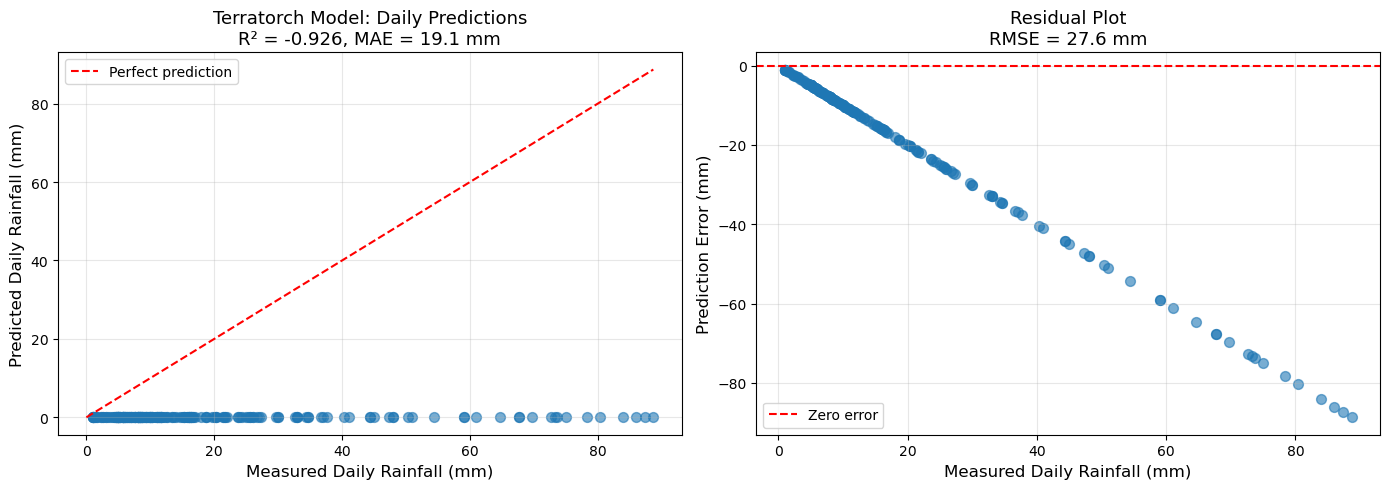


✅ Results saved to ../checkpoints/terratorch_daily_test_results.png
✅ Results saved to ../checkpoints/terratorch_daily_test_results.pkl


In [1]:
# =============================================================================
# EVALUATE MODELS ON DAILY TEST SET
# =============================================================================
# This notebook evaluates both the stacked CNN and TerraTorch models
# on the daily rainfall test set.
# 
# Process:
# 1. Load test dataset (hourly samples)
# 2. Group by (date, station_id)
# 3. Predict each hour → sum to daily total
# 4. Compare to daily gauge measurements
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# =============================================================================
# SECTION 1: Load Test Dataset
# =============================================================================

def load_test_dataset(test_pickle_path):
    """Load daily test dataset"""
    with open(test_pickle_path, 'rb') as f:
        data = pickle.load(f)
    
    print("="*60)
    print("DAILY TEST DATASET")
    print("="*60)
    print(f"Total hourly samples: {len(data['test'])}")
    print(f"Gauge type: {data['metadata']['gauge_type']}")
    print(f"Datastreams: {data['metadata']['datastreams']}")
    print(f"\nStations:")
    for station in data['metadata']['stations']:
        print(f"  - {station['station_name']}")
    
    return data

test_data = load_test_dataset('../deep_learning/radar_gauge_test_daily_76.pkl')

# Group samples by (date, station_id)
daily_groups = defaultdict(list)
for sample in test_data['test']:
    key = (sample['date'], sample['station_id'], sample['station_name'])
    daily_groups[key].append(sample)

print(f"\n✓ Grouped into {len(daily_groups)} unique day-station combinations")

# =============================================================================
# SECTION 2: Model Architectures (Copy from training notebooks)
# =============================================================================

# --- Stacked Model Architecture ---
class RadarEncoder(nn.Module):
    """
    CNN encoder for radar reflectivity data.
    Adapted from paper architecture for small 5×5 spatial input.
    
    Architecture:
    - Max over altitude dimension (Z) → (batch, 6, 5, 5)
    - Conv-BN-Pool-Dropout blocks (2 blocks instead of 4 due to small spatial size)
    - Flatten and FC layers
    - Output: latent embedding for fusion with DEM features
    """
    
    def __init__(self, in_channels=12, latent_dim=256, dropout_rate=0.25):
        super(RadarEncoder, self).__init__()
        
        # First conv block: 6 → 32 channels
        # Input: (24, 5, 5), Output: (32, 5, 5)
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.dropout1 = nn.Dropout2d(p=dropout_rate)
        
        # Second conv block with pooling: 32 → 64 channels
        # After conv: (64, 5, 5), After pool: (64, 2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)  # 5×5 → 2×2
        self.dropout2 = nn.Dropout2d(p=dropout_rate)
        
        # Third conv block: 64 → 128 channels
        # Output: (128, 2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.dropout3 = nn.Dropout2d(p=dropout_rate)
        
        # Flatten: 128 * 2 * 2 = 512
        self.fc1 = nn.Linear(128 * 2 * 2, 256)
        self.dropout_fc1 = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(256, latent_dim)
        
        print(f"RadarEncoder initialized: {in_channels} channels → {latent_dim} latent dims")
    
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: (batch, 6, Z, 5, 5) radar reflectivity
            
        Returns:
            embeddings: (batch, latent_dim) feature vector
        """        

        # Conv block 1
        x = F.relu(self.bn1(self.conv1(x)))  # (batch, 32, 5, 5)
        x = self.dropout1(x)
        
        # Conv block 2 with pooling
        x = F.relu(self.bn2(self.conv2(x)))  # (batch, 64, 5, 5)
        x = self.pool2(x)                     # (batch, 64, 2, 2)
        x = self.dropout2(x)
        
        # Conv block 3
        x = F.relu(self.bn3(self.conv3(x)))  # (batch, 128, 2, 2)
        x = self.dropout3(x)
        
        # Flatten and FC layers
        x = torch.flatten(x, 1)              # (batch, 512)
        x = F.relu(self.fc1(x))              # (batch, 256)
        embeddings = self.fc2(x)             # (batch, latent_dim)
        
        return embeddings


class PrecipitationDecoder(nn.Module):
    """
    Decoder to produce 5×5 precipitation map from fused features.
    Uses LayerNorm instead of BatchNorm (works with any batch size).
    """
    
    def __init__(self, input_dim=512, hidden_dim=256, output_size=5):
        super(PrecipitationDecoder, self).__init__()
        
        self.output_size = output_size
        
        # MLP to decode fused features with LayerNorm
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # 512 → 256
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.dropout1 = nn.Dropout(0.05)
        
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)  # 256 → 128
        self.ln2 = nn.LayerNorm(hidden_dim // 2)
        self.dropout2 = nn.Dropout(0.05)
        
        # Output layer: 25 values for 5×5 grid
        self.fc_out = nn.Linear(hidden_dim // 2, output_size * output_size)  # 128 → 25
        
        print(f"PrecipitationDecoder initialized: {input_dim} → {hidden_dim} → {hidden_dim // 2} → {output_size}×{output_size}")
    
    def forward(self, x):
        """Forward pass"""
        x = F.relu(self.ln1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = F.relu(self.ln2(self.fc2(x)))
        x = self.dropout2(x)
        
        # Output precipitation values - NO final ReLU!
        # MSE loss will naturally encourage positive predictions
        # Removing ReLU prevents dead neurons (58.5% were stuck at 0!)
        x = self.fc_out(x)
        
        # Reshape to 5×5 grid
        x = x.view(-1, self.output_size, self.output_size)
        
        return x

class PrecipitationDEMModel(nn.Module):
    """
    Complete model for precipitation prediction.
    
    Combines radar and DEM to predict 5×5 precipitation maps.
    """
    
    def __init__(self, latent_dim=256, n_radar_scans=12):
        super(PrecipitationDEMModel, self).__init__()
        
        # Encoders
        radar_channels = n_radar_scans * 3 + 1 # a mask channel for each radar scan + dem channel
        self.radar_encoder = RadarEncoder(
            in_channels=radar_channels, 
            latent_dim=latent_dim
        )
        
        self.bias_embedding = nn.Embedding(
            num_embeddings=3,    # -1, 0, +1
            embedding_dim=32     # Small dimension
        )
        
        # Decoder (takes encoder output + optional bias)
        decoder_input_dim = 256 + 32
        self.decoder = PrecipitationDecoder(
            input_dim=decoder_input_dim,
            hidden_dim=512
        )
    
    def forward(self, radar, bias_flag=None):
        """
        Forward pass
        
        Args:
            radar: (batch, 25, Z, 5, 5) radar reflectivity
            
        Returns:
            precip_map: (batch, 5, 5) precipitation map in mm/hr
        """
        # Encode radar
        radar_emb = self.radar_encoder(radar)  # (batch, latent_dim)

        if bias_flag is not None:
            bias_idx = (bias_flag + 1).long()
            bias_emb = self.bias_embedding(bias_idx)
            
            combined = torch.cat([radar_emb, bias_emb], dim=1)  # (batch, 288)
            pred_map = self.decoder(combined)  # (batch, 5, 5)
        else:
            pred_map = self.decoder(radar_emb)
            
        return pred_map

# --- TerraTorch Custom Decoder (required for loading checkpoint) ---
class SpatialPrecipitationDecoder(nn.Module):
    """
    Decodes spatial features to a 5×5 precipitation map.
    Compatible with TerraTorch's multi-scale feature lists.
    """
    includes_head = False

    def __init__(self, in_channels=192, target_size=5, output_bias=2.0):
        super().__init__()
        
        self.out_channels = 1
        
        self.conv1 = nn.Conv2d(in_channels, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        
        self.conv2 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        
        self.conv_out = nn.Conv2d(32, 1, kernel_size=1)
        self.final_pool = nn.AdaptiveAvgPool2d((target_size, target_size))

        with torch.no_grad():
            self.conv_out.bias.data.fill_(output_bias)
        
    def forward(self, x):
        """
        Input: List of feature tensors OR single tensor
        Output: (batch, 1, 5, 5) - precipitation map
        """
        # === HANDLE LIST INPUT FROM TERRATORCH ===
        if isinstance(x, list):
            # Take the last feature map (highest-level features)
            x = x[-1]
        
        # If features are (batch, patches, channels), reshape to spatial
        if x.dim() == 3:
            batch_size, num_patches, feat_dim = x.shape
            H = W = int(num_patches ** 0.5)  # e.g., 256 patches → 16×16
            x = x.transpose(1, 2).reshape(batch_size, feat_dim, H, W)
        
        # Now x should be (batch, channels, H, W)
        x = F.relu(self.bn1(self.conv1(x)))  # (B, 128, H, W)
        x = F.relu(self.bn2(self.conv2(x)))  # (B, 64, H, W)
        x = F.relu(self.bn3(self.conv3(x)))  # (B, 32, H, W)
        
        x = self.conv_out(x)  # (B, 1, H, W)
        x = self.final_pool(x)  # (B, 1, 5, 5)
        
        # DON'T squeeze - TerraTorch expects (B, C, H, W) output
        return x  # (B, 1, 5, 5)

# =============================================================================
# SECTION 3: Load Models
# =============================================================================

def load_stack_model(checkpoint_path):
    """Load stacked CNN model"""
    model = PrecipitationDEMModel(n_radar_scans=12, latent_dim=256)
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    model.to(device)
    
    print(f"✓ Loaded stacked model from {checkpoint_path}")
    print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}")
    print(f"  Val MAE: {checkpoint.get('val_mae', 'N/A'):.3f} mm/hr")
    
    return model

def load_terratorch_model(checkpoint_path):
    """Load TerraTorch model"""
    from terratorch.tasks import PixelwiseRegressionTask
    
    model = PixelwiseRegressionTask.load_from_checkpoint(checkpoint_path)
    model.eval()
    model.to(device)
    
    print(f"✓ Loaded TerraTorch model from {checkpoint_path}")
    
    return model

# Load your chosen model
MODEL_TYPE = 'terratorch'  # Change to 'terratorch' for TerraTorch model

if MODEL_TYPE == 'stack':
    model = load_stack_model('../checkpoints/stack_bias3_weights_70_mae_31r2.pth')
elif MODEL_TYPE == 'terratorch':
    checkpoint_dir = Path('../checkpoints/terratorch_5x5_time_unfreeze_weights_bias_3')
    checkpoint_files = list(checkpoint_dir.glob('best-*.ckpt'))
    best_ckpt = str(max(checkpoint_files, key=lambda p: p.stat().st_mtime))
    model = load_terratorch_model(best_ckpt)

# =============================================================================
# SECTION 4: Helper Functions
# =============================================================================

def prepare_stack_input(sample):
    """
    Prepare input for stacked model - MUST match training preprocessing!
    
    Training creates 37 channels:
      - radar_maxz: 12 channels (max over Z dimension)
      - mask_maxz: 12 channels (validity mask)
      - t_pos: 12 channels (temporal position 0-1)
      - dem: 1 channel (downsampled DEM)
    """
    DBZ_MIN = -32.0
    DBZ_MAX = 70.0
    
    radar_patch = sample['radar_patch']  # (12, 40, 5, 5)
    
    # Handle missing data (match training)
    radar_patch = np.where(radar_patch == -9999.0, DBZ_MIN, radar_patch)
    radar_patch = np.where(np.isnan(radar_patch), DBZ_MIN, radar_patch)
    
    # Normalize to [0, 1] (match training!)
    radar_norm = (radar_patch - DBZ_MIN) / (DBZ_MAX - DBZ_MIN)
    radar_norm = np.clip(radar_norm, 0, 1)
    
    # Create mask (1.0 = valid, 0.0 = padding)
    mask = np.ones_like(radar_norm)
    for i, ridx in enumerate(sample.get('radar_indices', [None]*12)):
        if ridx is None:
            mask[i, :, :, :] = 0.0
            radar_norm[i, :, :, :] = 0.0
    
    # Max over Z dimension (like training!)
    radar_maxz = np.max(radar_norm, axis=1)  # (12, 5, 5)
    mask_maxz = np.max(mask, axis=1)         # (12, 5, 5)
    
    # Temporal position channels (like training!)
    t_pos = np.zeros_like(radar_maxz)
    for i in range(12):
        t_pos[i] = i / 11.0
    
    # DEM - downsample to 5x5
    dem_patch = sample.get('dem_patch')
    if dem_patch is not None:
        dem_tensor = torch.from_numpy(dem_patch).float()
        dem_downsampled = F.adaptive_avg_pool2d(dem_tensor, (5, 5)).numpy()  # (1, 5, 5)
    else:
        # Use zeros if DEM not available
        dem_downsampled = np.zeros((1, 5, 5), dtype=np.float32)
    
    # Concatenate all channels: 12 + 12 + 12 + 1 = 37
    radar_input = np.concatenate([
        radar_maxz,       # 12 channels
        mask_maxz,        # 12 channels  
        t_pos,            # 12 channels
        dem_downsampled   # 1 channel
    ], axis=0)  # (37, 5, 5)
    
    # Convert to tensor
    radar_tensor = torch.from_numpy(radar_input).float().unsqueeze(0)  # (1, 37, 5, 5)
    
    # Bias flag
    bias_tensor = torch.tensor([1], dtype=torch.long)  # Neutral bias
    
    return radar_tensor.to(device), bias_tensor.to(device)

def prepare_terratorch_input(sample):
    """
    Prepare input for TerraTorch model - MUST match training preprocessing!
    
    Training creates:
      - RADAR: 36 channels (12 radar_maxz + 12 mask + 12 tpos) @ 256×256
      - DEM: 1 channel @ 256×256
    """
    DBZ_MIN = -32.0
    DBZ_MAX = 70.0
    
    radar_patch = sample['radar_patch']  # (12, 40, 5, 5)
    
    # Handle missing data (match training)
    radar_arr = radar_patch.copy()
    radar_arr[radar_arr == -9999.0] = DBZ_MIN
    radar_arr = np.where(np.isnan(radar_arr), DBZ_MIN, radar_arr)
    
    # Normalize to [0, 1]
    radar_norm = (radar_arr - DBZ_MIN) / (DBZ_MAX - DBZ_MIN)
    radar_norm = np.clip(radar_norm, 0, 1)
    
    # Create mask
    mask = np.ones_like(radar_norm)
    for i, ridx in enumerate(sample.get('radar_indices', [None]*12)):
        if ridx is None:
            mask[i, :, :, :] = 0.0
            radar_norm[i, :, :, :] = 0.0
    
    # Convert to tensors
    radar_t = torch.from_numpy(radar_norm).float()  # (12, 40, 5, 5)
    mask_t = torch.from_numpy(mask).float()         # (12, 40, 5, 5)
    
    # Max over Z dimension
    radar_maxz, _ = torch.max(radar_t, dim=1)  # (12, 5, 5)
    mask_maxz, _ = torch.max(mask_t, dim=1)    # (12, 5, 5)
    
    # Temporal position channels
    t_pos = torch.zeros_like(radar_maxz)
    for i in range(12):
        t_pos[i] = i / 11.0
    
    # Stack: (36, 5, 5)
    radar_all = torch.cat([radar_maxz, mask_maxz, t_pos], dim=0)
    
    # Upscale to 256×256 (match training!)
    radar_up = F.interpolate(
        radar_all.unsqueeze(0),
        size=(256, 256),
        mode='nearest'
    ).squeeze(0)  # (36, 256, 256)
    
    # Process DEM
    dem_patch = sample.get('dem_patch')
    if dem_patch is not None:
        dem_tensor = torch.from_numpy(dem_patch).float()  # (1, H, W)
        # Resize to 256×256
        dem_up = F.interpolate(
            dem_tensor.unsqueeze(0),
            size=(256, 256),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)  # (1, 256, 256)
    else:
        dem_up = torch.zeros(1, 256, 256)
    
    # Create input dict with modalities (match TerraTorch training)
    radar_batch = radar_up.unsqueeze(0).to(device)  # (1, 36, 256, 256)
    dem_batch = dem_up.unsqueeze(0).to(device)      # (1, 1, 256, 256)
    
    input_dict = {
        'RADAR': radar_batch,
        'DEM': dem_batch
    }
    
    return input_dict

# =============================================================================
# SECTION 5: Evaluate on Daily Test Set
# =============================================================================

def evaluate_daily(model, daily_groups, model_type='stack'):
    """
    Evaluate model on daily test set
    
    Returns:
        results: list of dicts with daily predictions and metrics
    """
    model.eval()
    results = []
    
    print(f"\n{'='*60}")
    print(f"EVALUATING {len(daily_groups)} DAYS")
    print(f"{'='*60}\n")
    
    with torch.no_grad():
        for (date, station_id, station_name), hourly_samples in tqdm(daily_groups.items(), desc="Days"):
            
            hourly_preds = []
            daily_truth = hourly_samples[0]['daily_precip_mm']
            
            # Predict each hour
            for sample in hourly_samples:
                if model_type == 'stack':
                    radar, bias = prepare_stack_input(sample)
                    pred_map_log = model(radar, bias)  # (1, 5, 5) - OUTPUT IS IN LOG SPACE!
                    pred_center_log = pred_map_log[0, 2, 2].item()  # Center pixel (log space)
                    pred_center = np.expm1(pred_center_log)  # Convert from log space to mm/hr!
                    
                elif model_type == 'terratorch':
                    input_dict = prepare_terratorch_input(sample)
                    output = model.model(input_dict)
                    pred_map_log = output.output  # (1, 1, 5, 5) in log space
                    pred_center_log = pred_map_log[0, 2, 2].item()
                    pred_center = np.expm1(pred_center_log)  # Convert to mm/hr
                
                hourly_preds.append(max(0, pred_center))  # Ensure non-negative
            
            # Sum to daily total
            daily_pred = sum(hourly_preds)
            
            results.append({
                'date': date,
                'station_id': station_id,
                'station_name': station_name,
                'n_hours': len(hourly_preds),
                'hourly_preds': hourly_preds,
                'daily_pred': daily_pred,
                'daily_truth': daily_truth,
                'error': daily_pred - daily_truth,
                'abs_error': abs(daily_pred - daily_truth),
                'pct_error': 100 * (daily_pred - daily_truth) / daily_truth if daily_truth > 0 else 0
            })
    
    return results

# Run evaluation
results = evaluate_daily(model, daily_groups, model_type=MODEL_TYPE)

# =============================================================================
# SECTION 6: Print Metrics
# =============================================================================

def print_metrics(results, model_name="Model"):
    """Print evaluation metrics"""
    
    preds = np.array([r['daily_pred'] for r in results])
    truths = np.array([r['daily_truth'] for r in results])
    
    mae = np.mean(np.abs(preds - truths))
    rmse = np.sqrt(np.mean((preds - truths)**2))
    
    ss_res = np.sum((truths - preds)**2)
    ss_tot = np.sum((truths - np.mean(truths))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    print(f"\n{'='*60}")
    print(f"{model_name.upper()} - DAILY TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"\n📊 Overall Metrics (n={len(results)} days):")
    print(f"  MAE:  {mae:.2f} mm/day")
    print(f"  RMSE: {rmse:.2f} mm/day")
    print(f"  R²:   {r2:.3f}")
    
    # Per-station breakdown
    print(f"\n📍 Per-Station Breakdown:")
    station_results = defaultdict(list)
    for r in results:
        station_results[r['station_name']].append(r)
    
    for station_name, station_res in sorted(station_results.items()):
        preds_s = np.array([r['daily_pred'] for r in station_res])
        truths_s = np.array([r['daily_truth'] for r in station_res])
        mae_s = np.mean(np.abs(preds_s - truths_s))
        print(f"  {station_name:30s}: {len(station_res):3d} days, MAE={mae_s:5.1f} mm/day")
    
    # Best predictions
    print(f"\n✅ Best Predictions (lowest absolute error):")
    sorted_by_error = sorted(results, key=lambda x: x['abs_error'])
    for r in sorted_by_error[:5]:
        print(f"  {str(r['date']):12s} {r['station_name']:25s}: pred={r['daily_pred']:5.1f}, truth={r['daily_truth']:5.1f}, error={r['error']:+6.1f} mm")
    
    # Worst predictions
    print(f"\n❌ Worst Predictions (highest absolute error):")
    for r in sorted_by_error[-5:][::-1]:
        print(f"  {str(r['date']):12s} {r['station_name']:25s}: pred={r['daily_pred']:5.1f}, truth={r['daily_truth']:5.1f}, error={r['error']:+6.1f} mm")
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

metrics = print_metrics(results, model_name=MODEL_TYPE)

# =============================================================================
# SECTION 7: Visualizations
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
preds = np.array([r['daily_pred'] for r in results])
truths = np.array([r['daily_truth'] for r in results])

ax.scatter(truths, preds, alpha=0.6, s=50)
ax.plot([0, truths.max()], [0, truths.max()], 'r--', label='Perfect prediction')
ax.set_xlabel('Measured Daily Rainfall (mm)', fontsize=12)
ax.set_ylabel('Predicted Daily Rainfall (mm)', fontsize=12)
ax.set_title(f'{MODEL_TYPE.title()} Model: Daily Predictions\nR² = {metrics["r2"]:.3f}, MAE = {metrics["mae"]:.1f} mm', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Residuals
ax = axes[1]
errors = preds - truths
ax.scatter(truths, errors, alpha=0.6, s=50)
ax.axhline(0, color='r', linestyle='--', label='Zero error')
ax.set_xlabel('Measured Daily Rainfall (mm)', fontsize=12)
ax.set_ylabel('Prediction Error (mm)', fontsize=12)
ax.set_title(f'Residual Plot\nRMSE = {metrics["rmse"]:.1f} mm', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'../checkpoints/{MODEL_TYPE}_daily_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Results saved to ../checkpoints/{MODEL_TYPE}_daily_test_results.png")

# Save results
results_path = f'../checkpoints/{MODEL_TYPE}_daily_test_results.pkl'
with open(results_path, 'wb') as f:
    pickle.dump({
        'results': results,
        'metrics': metrics,
        'model_type': MODEL_TYPE,
        'test_metadata': test_data['metadata']
    }, f)

print(f"✅ Results saved to {results_path}")